c:\Users\1033\.conda\envs\envs\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\1033\.conda\envs\envs\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


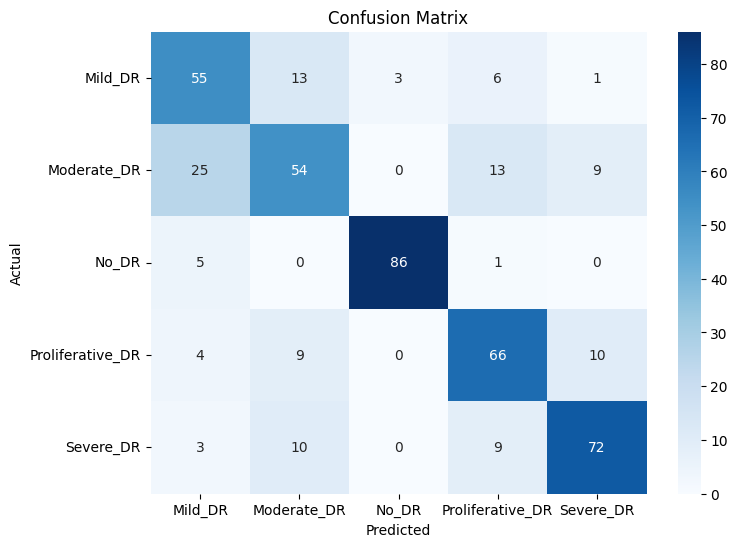

Classification Report:

                  precision    recall  f1-score   support

         Mild_DR       0.60      0.71      0.65        78
     Moderate_DR       0.63      0.53      0.58       101
           No_DR       0.97      0.93      0.95        92
Proliferative_DR       0.69      0.74      0.72        89
       Severe_DR       0.78      0.77      0.77        94

        accuracy                           0.73       454
       macro avg       0.73      0.74      0.73       454
    weighted avg       0.74      0.73      0.73       454



In [1]:
import os
import torch
import numpy as np
from torch import nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Path to your dataset folder
dataset_folder = r"Z:\Shaik_shariff\ARJUN\MAY\EffNet-SVM_A_Hybrid_Model_for_Diabetic_Retinopathy_Classification_Using_Retinal_Fundus_Images\DATASET\data_modfi\train_new"
# Define image transformations
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Pretrained mean and std
])

# Define the custom dataset
class CustomDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.class_names = os.listdir(folder_path)
        self.image_paths = []
        self.labels = []
        
        for label, class_name in enumerate(self.class_names):
            class_folder = os.path.join(folder_path, class_name)
            image_files = [f for f in os.listdir(class_folder) if f.endswith(('jpg', 'jpeg', 'png'))]
            for image_file in image_files:
                self.image_paths.append(os.path.join(class_folder, image_file))
                self.labels.append(label)
                
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Load the dataset
dataset = CustomDataset(dataset_folder, transform=transform)

# Split dataset into train and validation
train_size = int(0.8 * len(dataset))  # 80% for training
val_size = len(dataset) - train_size  # 20% for validation
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Dataloader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load the EfficientNetB0 model
model = models.efficientnet_b0(pretrained=True)
model.classifier = nn.Identity()  # Remove classifier head
model = model.to(device)

# Function to extract features using EfficientNet
def extract_features(loader):
    model.eval()
    all_features = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            features = model(images)
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())
    
    return np.vstack(all_features), np.concatenate(all_labels)

# Extract features from the training data
train_features, train_labels = extract_features(train_loader)

# Extract features from the validation data
val_features, val_labels = extract_features(val_loader)

# Initialize the SVM model
svm_model = SVC(kernel='linear')

# Train the SVM model on the extracted features
svm_model.fit(train_features, train_labels)

# Make predictions on the validation data
val_predictions = svm_model.predict(val_features)

# Evaluate the model using confusion matrix and classification report
conf_matrix = confusion_matrix(val_labels, val_predictions)
class_report = classification_report(val_labels, val_predictions, target_names=dataset.class_names)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_names, yticklabels=dataset.class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Display classification report
print("Classification Report:\n")
print(class_report)


In [3]:
import joblib

# Save the trained SVM model to a file
joblib.dump(svm_model, 'svm_effitnet_trained.pkl')


['svm_effitnet_trained.pkl']

c:\Users\1033\.conda\envs\envs\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\1033\.conda\envs\envs\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


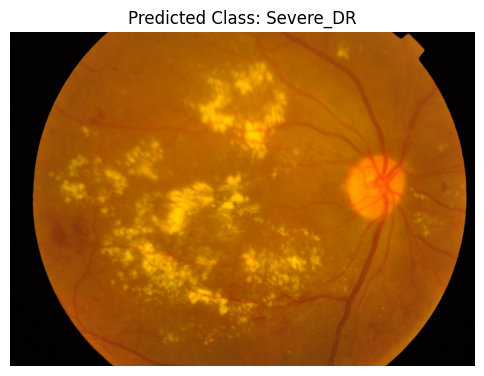

Predicted Class: Severe_DR


In [4]:
import torch
import numpy as np
from torchvision import models, transforms
from PIL import Image
import joblib
import matplotlib.pyplot as plt

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the trained SVM model
svm_model = joblib.load('svm_effitnet_trained.pkl')

# Load the EfficientNet model for feature extraction
model = models.efficientnet_b0(pretrained=True)
model.classifier = torch.nn.Identity()  # Remove classifier head
model = model.to(device)
model.eval()  # Set model to evaluation mode

# Define image transformations (same as used during training)
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Pretrained mean and std
])

# Function to extract features from a single image
def extract_features_from_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device
    
    with torch.no_grad():
        features = model(image)  # Extract features using EfficientNet
        return features.cpu().numpy().flatten()  # Flatten and move to CPU

# Prediction function for a single image
def predict_image(image_path):
    # Extract features from the image
    features = extract_features_from_image(image_path)
    
    # Predict using the saved SVM model
    prediction = svm_model.predict([features])
    
    # Class mapping (make sure it matches the target_classes used during training)
    target_classes = ['Mild_DR', 'Moderate_DR', 'No_DR', 'Proliferative_DR', 'Severe_DR']
    
    predicted_class = target_classes[prediction[0]]
    
    # Display the image
    image = Image.open(image_path)
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.title(f"Predicted Class: {predicted_class}")
    plt.axis('off')  # Turn off axis
    plt.show()
    
    return predicted_class

# Example usage: predict a single image
image_path = r"Z:\Shaik_shariff\ARJUN\MAY\EffNet-SVM_A_Hybrid_Model_for_Diabetic_Retinopathy_Classification_Using_Retinal_Fundus_Images\DATASET\data_modfi\train_new\Severe_DR\0f96c358a250.png"
predicted_class = predict_image(image_path)

print(f"Predicted Class: {predicted_class}")


c:\Users\1033\.conda\envs\envs\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\1033\.cache\huggingface\hub\models--microsoft--swin-tiny-patch4-window7-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Epoch 1/20, Loss: 0.9614207608657971, Accuracy: 59.94490358126722%
Validation Accuracy: 67.62114537444934%
Epoch 2/20, Loss: 0.6058767453620308, Accuracy: 74.93112947658402%
Validation Accuracy: 75.77092511013215%
Epoch 3/20, Loss: 0.4909159164679678, Accuracy: 81.26721763085399%
Validation Accuracy: 79.0748898678414%
Epoch 4/20, Loss: 0.375230054322042, Accuracy: 85.23415977961433%
Validation Accuracy: 75.55066079295155%
Epoch 5/20, Loss: 0.27927349638520627, Accuracy: 89.80716253443526%
Validation Accuracy: 76.87224669603525%
Epoch 6/20, Loss: 0.1898838826046701, Accuracy: 93.22314049586777%
Validation Accuracy: 77.09251101321586%
Epoch 7/20, Loss: 0.170145923761945, Accuracy: 93.93939393939394%
Validation Accuracy: 75.77092511013215%
Epoch 8/20, Loss: 0.09915410915977861, Accuracy: 96.74931129476585%
Validation Accuracy: 75.55066079295155%
Epoch 9/20, Loss: 0.09990570035746746, Accuracy: 96.63911845730027%
Validation Accuracy: 77.31277533039648%
Epoch 10/20, Loss: 0.0520605835062860

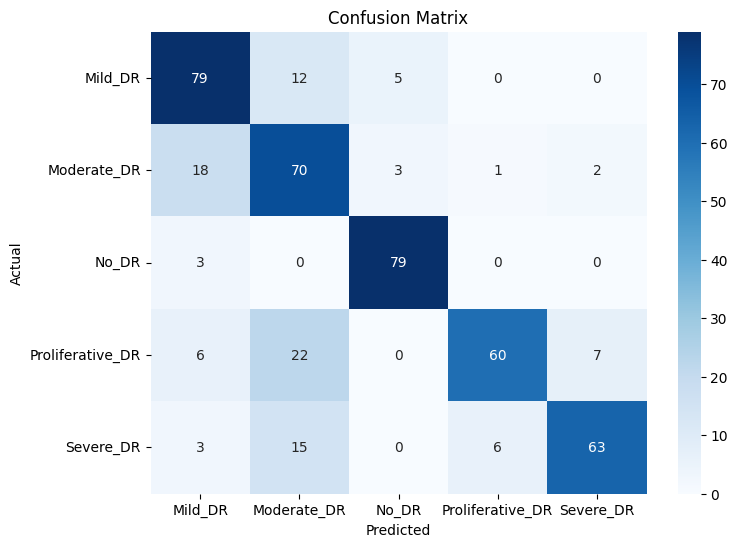

Classification Report:

                  precision    recall  f1-score   support

         Mild_DR       0.72      0.82      0.77        96
     Moderate_DR       0.59      0.74      0.66        94
           No_DR       0.91      0.96      0.93        82
Proliferative_DR       0.90      0.63      0.74        95
       Severe_DR       0.88      0.72      0.79        87

        accuracy                           0.77       454
       macro avg       0.80      0.78      0.78       454
    weighted avg       0.79      0.77      0.77       454



In [ ]:
import os
import numpy as np
import torch
from torch import nn, optim
from transformers import SwinForImageClassification, SwinConfig
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

dataset_folder = r"Z:\Shaik_shariff\ARJUN\MAY\EffNet-SVM_A_Hybrid_Model_for_Diabetic_Retinopathy_Classification_Using_Retinal_Fundus_Images\DATASET\data_modfi\train_new"
# Define target classes manually as per your previous setup
target_classes = ['Mild_DR', 'Moderate_DR', 'No_DR', 'Proliferative_DR', 'Severe_DR']

# Initialize Swin Transformer model from Hugging Face
model = SwinForImageClassification.from_pretrained('microsoft/swin-tiny-patch4-window7-224')

# Replace the classifier head with a custom one (as we have 5 classes)
model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, len(target_classes))  # 5 output classes
)

# Define image transformation (to resize and normalize the images)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize as per Swin's original settings
])

# Custom Dataset class to load images from the folder
class RetinalDataset(Dataset):
    def __init__(self, dataset_folder, target_classes, transform=None):
        self.dataset_folder = dataset_folder
        self.target_classes = target_classes
        self.transform = transform
        self.images = []
        self.labels = []
        
        # Collecting images and labels
        for label, class_name in enumerate(target_classes):
            class_path = os.path.join(dataset_folder, class_name)
            for img_name in os.listdir(class_path):
                if img_name.endswith(('jpg', 'jpeg', 'png')):
                    self.images.append(os.path.join(class_path, img_name))
                    self.labels.append(label)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")  # Convert to RGB if not
        label = self.labels[idx]
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

# Initialize dataset and dataloaders
dataset = RetinalDataset(dataset_folder, target_classes, transform)
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [int(0.8 * len(dataset)), len(dataset) - int(0.8 * len(dataset))])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Save the best model based on validation accuracy
best_val_accuracy = 0.0
best_model_wts = model.state_dict()

# Training loop
epochs = 20
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(imgs).logits
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader)}, Accuracy: {train_accuracy}%")

    # Validation phase
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            
            outputs = model(imgs).logits
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_accuracy = 100 * correct / total
    print(f"Validation Accuracy: {val_accuracy}%")
    
    # Save the best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_wts = model.state_dict()

# Load the best model weights
model.load_state_dict(best_model_wts)

# Evaluate the model
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        outputs = model(imgs).logits
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
class_report = classification_report(all_labels, all_preds, target_names=target_classes)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_classes, yticklabels=target_classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Display classification report
print("Classification Report:\n")
print(class_report)


In [9]:
# After training is completed, save the best model (weights)
torch.save(model.state_dict(), 'best_swin_model.pth')
print("Model saved as 'best_swin_model.pth'")


Model saved as 'best_swin_model.pth'


c:\Users\1033\.conda\envs\envs\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


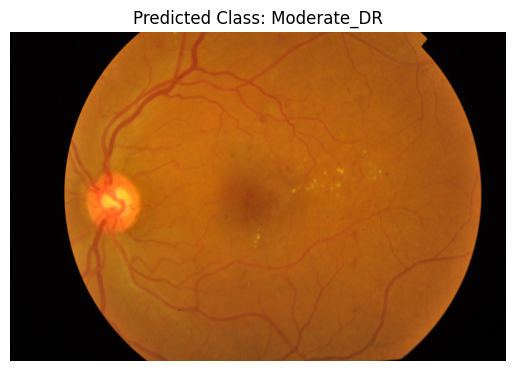

Predicted Class: Moderate_DR


In [1]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from transformers import SwinForImageClassification
import numpy as np

# Load the pre-trained model
model = SwinForImageClassification.from_pretrained('microsoft/swin-tiny-patch4-window7-224')

# Replace the classifier head with a custom one (as we have 5 classes)
target_classes = ['Mild_DR', 'Moderate_DR', 'No_DR', 'Proliferative_DR', 'Severe_DR']
model.classifier = torch.nn.Sequential(
    torch.nn.Linear(model.classifier.in_features, 1024),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.5),
    torch.nn.Linear(1024, len(target_classes))  # 5 output classes
)

# Load the model weights (if saved)
model.load_state_dict(torch.load('best_swin_model.pth'))
model.eval()  # Set the model to evaluation mode

# Define image transformation (same as during training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize as per Swin's original settings
])

# Function to predict the class of a single image
def predict_image(image_path):
    # Open the image
    image = Image.open(image_path).convert("RGB")

    # Preprocess the image
    image_tensor = transform(image).unsqueeze(0)  # Add batch dimension

    # Make prediction
    with torch.no_grad():
        outputs = model(image_tensor)
        logits = outputs.logits
        _, predicted_class = torch.max(logits, 1)
    
    # Get predicted class
    predicted_class_label = target_classes[predicted_class.item()]

    # Display the image with the predicted label
    plt.imshow(image)
    plt.title(f"Predicted Class: {predicted_class_label}")
    plt.axis('off')  # Hide axes
    plt.show()

    return predicted_class_label

# Example usage: predict a single image
image_path = r"Z:\Shaik_shariff\ARJUN\MAY\EffNet-SVM_A_Hybrid_Model_for_Diabetic_Retinopathy_Classification_Using_Retinal_Fundus_Images\DATASET\data_modfi\val_new\Moderate_DR\0afdfe5f422c.png" # Replace with the path to the image you want to predict
predicted_class = predict_image(image_path)

print(f"Predicted Class: {predicted_class}")

